# Atelier Preparation de Donnees Textuelles

## Partie 1 – Exploration du corpus

### 1) Charger les données CSV

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 120)

df = pd.read_csv('../data/smart_reviews_raw.csv')
df.head()

,id_avis,date,source,produit,texte,sentiment,note,langue
0,AV0001,2026-02-27,mobile,Ordinateur NovaBook,"Très bonne expérience, simple et efficace.",positif,4,fr
1,AV0002,2026-01-09,web,SmartPhone X,Très satisfait de mon achat 👍 #avis,positif,4,fr
2,AV0003,2026-07-03,réseaux_sociaux,Écouteurs AirSound,"Produit parfait, rien à signaler.",positif,4,fr
3,AV0004,2026-06-28,sav,SmartWatch Pro,"Produit excellent, je suis très satisfait. !!!",positif,5,fr
4,AV0005,2026-01-24,sav,SmartPhone X,LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE.,positif,5,fr


### 2) Combien d'avis contient le dataset ?

In [2]:
nb_avis = df.shape[0]
print(f"Le dataset contient {nb_avis} avis.")

Le dataset contient 1200 avis.


### 3) Combien de colonnes possède-t-il ?

In [3]:
nb_colonnes = df.shape[1]
print(f"Le dataset possède {nb_colonnes} colonnes : {list(df.columns)}")

Le dataset possède 8 colonnes : ['id_avis', 'date', 'source', 'produit', 'texte', 'sentiment', 'note', 'langue']


### 4) Quel est le type de chaque colonne ?

In [4]:
df.dtypes

id_avis        str
date           str
source         str
produit        str
texte          str
sentiment      str
note         int64
langue         str
dtype: object

### 5) Existe-t-il des valeurs manquantes ?

In [5]:
df.isna().sum()

id_avis      0
date         0
source       0
produit      0
texte        5
sentiment    0
note         0
langue       0
dtype: int64

### 6) Identifier quelques types de texte

In [6]:
url_re = re.compile(r'https?://\S+|www\.\S+')
mention_re = re.compile(r'@\w+')
hashtag_re = re.compile(r'#\w+')
emoji_re = re.compile(r'[\U0001F300-\U0001FAFF\U00002600-\U000027BF]')
ponct_re = re.compile(r'[!?.,;:]{3,}')
repetition_re = re.compile(r'(.)\1{2,}')

texte_series = df['texte'].fillna('')

exemples = {
    'texte normal': texte_series[texte_series.str.match(r'^[A-Za-zÀ-ÿ ,.\'\-]+$', na=False)].iloc[0] if not texte_series[texte_series.str.match(r'^[A-Za-zÀ-ÿ ,.\'\-]+$', na=False)].empty else None,
    'texte vide': df.loc[df['texte'].isna() | (df['texte'].str.strip() == ''), 'texte'].iloc[0] if df['texte'].isna().any() else '(aucun trouve)',
    'texte avec URL': texte_series[texte_series.str.contains(url_re)].iloc[0],
    'texte avec mention': texte_series[texte_series.str.contains(mention_re)].iloc[0],
    'texte avec hashtag': texte_series[texte_series.str.contains(hashtag_re)].iloc[0],
    'texte avec emojis': texte_series[texte_series.str.contains(emoji_re)].iloc[0],
    'texte avec beaucoup de ponctuation': texte_series[texte_series.str.contains(ponct_re)].iloc[0],
    'texte en majuscules': texte_series[texte_series.str.isupper() & (texte_series.str.len() > 5)].iloc[0],
    'texte avec repetition de caracteres': texte_series[texte_series.str.contains(repetition_re)].iloc[0],
}

for cle, valeur in exemples.items():
    print(f"- {cle} : {valeur!r}")

- texte normal : 'Très  bonne  expérience,  simple  et  efficace.'
- texte vide : nan
- texte avec URL : 'Produit parfait, rien à signaler. https://example.com/commande/17'
- texte avec mention : '@client Livraison rapide et produit conforme à mes attentes.'
- texte avec hashtag : 'Très satisfait de mon achat 👍 #avis'
- texte avec emojis : 'Très satisfait de mon achat 👍 #avis'
- texte avec beaucoup de ponctuation : 'Produit excellent, je suis très satisfait. !!!'
- texte en majuscules : "LA BATTERIE TIENT VRAIMENT BIEN ET L'ÉCRAN EST SUPERBE."
- texte avec repetition de caracteres : 'Produit excellent, je suis très satisfait. !!!'


C:\Users\NGOM PC\AppData\Local\Temp\ipykernel_16336\2146999153.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  'texte avec repetition de caracteres': texte_series[texte_series.str.contains(repetition_re)].iloc[0],


### 7) Longueur des textes

In [7]:
df['longueur'] = df['texte'].fillna('').str.len()

stats_longueur = {
    'min': df['longueur'].min(),
    'max': df['longueur'].max(),
    'moyenne': df['longueur'].mean(),
    'mediane': df['longueur'].median(),
    'Q1': df['longueur'].quantile(0.25),
    'Q3': df['longueur'].quantile(0.75),
}
for k, v in stats_longueur.items():
    print(f"{k} : {v:.2f}")

min : 0.00
max : 636.00
moyenne : 48.96
mediane : 48.00
Q1 : 37.00
Q3 : 56.00


### 8) Visualisation de la distribution de la longueur des avis

C:\Users\NGOM PC\AppData\Local\Temp\ipykernel_16336\1971241726.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['longueur'], vert=True)


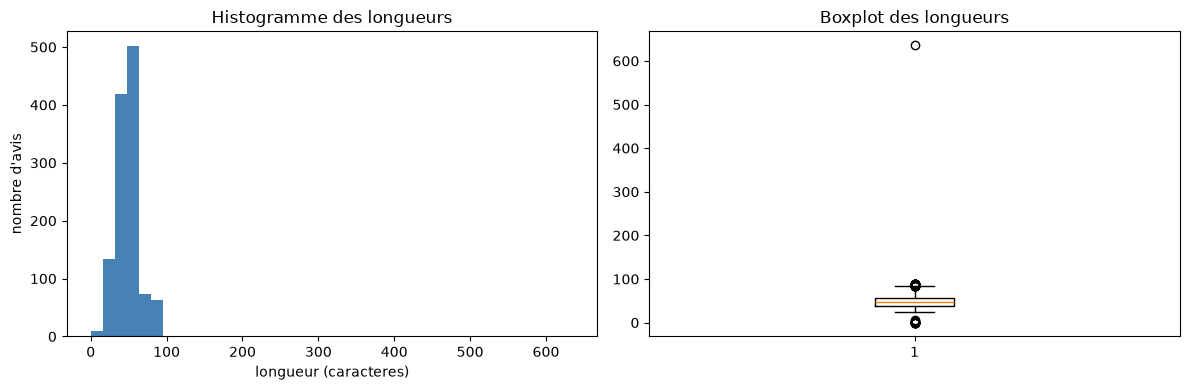

Nombre de textes au-dela du 99e percentile (87 caracteres) : 11
Nombre de textes tres courts (< 10 caracteres) : 9


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['longueur'], bins=40, color='steelblue')
axes[0].set_title('Histogramme des longueurs')
axes[0].set_xlabel('longueur (caracteres)')
axes[0].set_ylabel("nombre d'avis")

axes[1].boxplot(df['longueur'], vert=True)
axes[1].set_title('Boxplot des longueurs')
plt.tight_layout()
plt.show()

seuil_long = df['longueur'].quantile(0.99)
seuil_court = 10
nb_longs = (df['longueur'] > seuil_long).sum()
nb_courts = (df['longueur'] < seuil_court).sum()
print(f"Nombre de textes au-dela du 99e percentile ({seuil_long:.0f} caracteres) : {nb_longs}")
print(f"Nombre de textes tres courts (< {seuil_court} caracteres) : {nb_courts}")

**a) Existe-t-il des textes anormalement longs ?**
Oui. La majorite des avis se situe entre 37 et 56 caracteres (Q1/Q3), mais le maximum atteint 636 caracteres et 11 avis depassent le 99e percentile (87 caracteres) : ce sont des valeurs aberrantes tres eloignees de la distribution generale, a surveiller lors du nettoyage.

**b) Existe-t-il beaucoup de textes tres courts ?**
Oui, dans une moindre mesure : 9 avis ont moins de 10 caracteres (dont les textes vides). Cela reste marginal (moins de 1% du corpus) mais ces avis tres courts risquent de porter peu d'information utile pour la classification de sentiment.

### 9) Detection des textes vides

In [9]:
textes_vides = df[df['texte'].isna() | (df['texte'].fillna('').str.strip() == '')]
print(f"Nombre de textes vides ou manquants : {len(textes_vides)}")
textes_vides[['id_avis', 'texte', 'sentiment']]

Nombre de textes vides ou manquants : 6


,id_avis,texte,sentiment
46,AV0047,NaN,positif
108,AV0109,NaN,positif
310,AV0311,NaN,positif
640,AV0641,NaN,positif
781,AV0782,NaN,neutre
951,AV0952,,positif


### 10) Detection des doublons sur le texte

In [10]:
doublons = df[df.duplicated(subset='texte', keep=False) & df['texte'].notna()].sort_values('texte')
print(f"Nombre de lignes impliquees dans un doublon de texte : {len(doublons)}")
print(f"Nombre de doublons (lignes en trop) : {df.duplicated(subset='texte').sum()}")
doublons[['id_avis', 'texte']].head(10)

Nombre de lignes impliquees dans un doublon de texte : 1031
Nombre de doublons (lignes en trop) : 881


,id_avis,texte
312,AV0313,@client Excellent rapport qualité-prix.
419,AV0420,@client Excellent rapport qualité-prix.
1099,AV1100,@client Excellent rapport qualité-prix.
45,AV0046,@client Excellent rapport qualité-prix.
466,AV0467,@client Excellent rapport qualité-prix.
1059,AV1060,@client Excellent rapport qualité-prix.
146,AV0147,@client Excellent rapport qualité-prix.
593,AV0594,@client Excellent rapport qualité-prix.
611,AV0612,@client Excellent rapport qualité-prix.
398,AV0399,@client Excellent rapport qualité-prix.


### 11) Les classes sont-elles equilibrees ?

In [11]:
repartition = df['sentiment'].value_counts()
proportions = df['sentiment'].value_counts(normalize=True) * 100
print(repartition)
print()
print(proportions.round(2))

sentiment
positif    776
neutre     246
negatif    178
Name: count, dtype: int64

sentiment
positif    64.67
neutre     20.50
negatif    14.83
Name: proportion, dtype: float64


Non, les classes ne sont pas equilibrees : `positif` represente 64.67% des avis (776), `neutre` 20.50% (246) et `negatif` 14.83% (178). La classe positive domine tres largement, ce qui constitue un desequilibre significatif a prendre en compte pour la modelisation et l'evaluation.

### 12) Quelle est la classe majoritaire ?

In [12]:
classe_majoritaire = df['sentiment'].value_counts().idxmax()
print(f"La classe majoritaire est : {classe_majoritaire}")

La classe majoritaire est : positif


### 13) Quelles metriques de classification envisager ?

In [13]:
baseline_accuracy = (df['sentiment'] == 'positif').mean()
print(f"Un modele qui predit toujours 'positif' obtiendrait une accuracy de {baseline_accuracy:.2%} sans rien avoir appris.")

Un modele qui predit toujours 'positif' obtiendrait une accuracy de 64.67% sans rien avoir appris.


Le jeu de donnees etant desequilibre (64.67% de `positif`), l'**accuracy seule est trompeuse** : un modele naif qui predit toujours la classe majoritaire obtient deja ~65% d'accuracy. Il faut donc privilegier :
- le **F1-score macro** (moyenne non ponderee des F1 par classe), qui penalise un modele incapable de detecter les classes minoritaires (`negatif`, `neutre`) ;
- la **precision** et le **rappel par classe**, pour savoir si le modele confond `neutre` et `negatif` avec `positif` ;
- la **matrice de confusion**, pour visualiser les erreurs entre classes ;
- eventuellement le **F1-score pondere** (weighted) pour une vue globale tenant compte du poids reel des classes.

### 14) Detection des caracteres particuliers

In [14]:
chiffres_re = re.compile(r'\d')
speciaux_re = re.compile(r'[^\w\s.,!?\'\-]', flags=re.UNICODE)

compteurs = {
    'emojis': texte_series.str.contains(emoji_re).sum(),
    'URLs': texte_series.str.contains(url_re).sum(),
    'hashtags': texte_series.str.contains(hashtag_re).sum(),
    'mentions': texte_series.str.contains(mention_re).sum(),
    'chiffres': texte_series.str.contains(chiffres_re).sum(),
    'caracteres speciaux': texte_series.str.contains(speciaux_re).sum(),
    'ponctuation repetee (!!!, ???, ...)': texte_series.str.contains(ponct_re).sum(),
}
for cle, valeur in compteurs.items():
    print(f"{cle} : {valeur} avis concernes")

emojis : 192 avis concernes
URLs : 143 avis concernes
hashtags : 127 avis concernes
mentions : 128 avis concernes
chiffres : 142 avis concernes
caracteres speciaux : 569 avis concernes
ponctuation repetee (!!!, ???, ...) : 141 avis concernes


### 15) Nombre d'avis par source

source
réseaux_sociaux    251
email              247
sav                239
web                232
mobile             230
WEB                  1
Name: count, dtype: int64


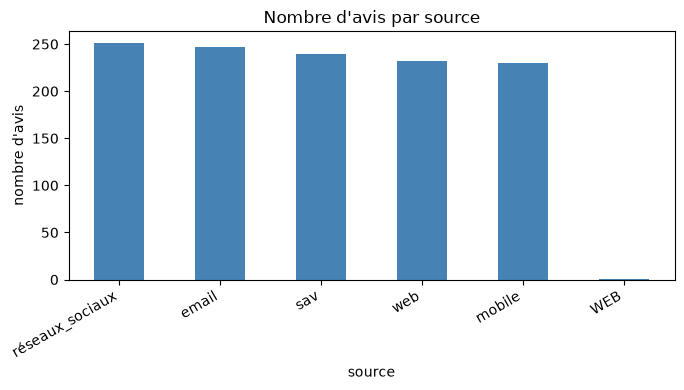

In [15]:
avis_par_source = df['source'].value_counts()
print(avis_par_source)

avis_par_source.plot(kind='bar', color='steelblue', figsize=(7, 4), title="Nombre d'avis par source")
plt.ylabel("nombre d'avis")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Les avis sont repartis de facon assez homogene entre les 5 sources (entre 230 et 251 avis chacune), sans source dominante. On note toutefois une incoherence de qualite : la valeur `WEB` (en majuscules, 1 occurrence) est en realite un doublon de categorie avec `web` du a une mauvaise normalisation de la casse a la collecte, et devra etre corrigee.